### EDA and Preprocessing Notebook (Part 1)

There are currently 3 datasets available, consisting of 97 data entries. The datasets are complementary to each other, with the datasets being the clinical data, raw FTIR samples from the data and also the cleaned version of the raw FTIR samples from a domain expert.

For this notebook (Part 1), we will be handling the clinical data only.

We will start by analysing the raw data:

In [2]:
import pandas as pd

df = pd.read_excel('../data/Clinical Data for Modeling.xlsx')

##### Quick Overview:

In [3]:
df.shape

(97, 22)

There will be 97 data instances, with 22 columns each.

In [4]:
df.columns

Index(['patient code_number of scan', 'grouping', 'AGE', 'RACE', 'PSA (ng/ml)',
       'Body Weight (Kg)', 'Height (cm)', 'Region',
       'Family History Prostate Cancer',
       'Family History of Lethal Prostate Cancer', 'Ethnicity',
       'Educational Background', 'Hypertension', 'Heart disease',
       'Cerebro-vascular disease', 'Hyperlipidemia', 'Diabetes Melitus',
       'Pulmonary disease', 'Gastric ulser', 'Renal disease', 'Other cancer',
       'Other disease'],
      dtype='object')

In [5]:
df.head()

,patient code_number of scan,grouping,AGE,RACE,PSA (ng/ml),Body Weight (Kg),Height (cm),Region,Family History Prostate Cancer,Family History of Lethal Prostate Cancer,...,Hypertension,Heart disease,Cerebro-vascular disease,Hyperlipidemia,Diabetes Melitus,Pulmonary disease,Gastric ulser,Renal disease,Other cancer,Other disease
0,C001_1,cancerous,68,C,7.92,71.0,172.0,Rural,1st degree relative,No,...,Yes,No,No,Yes,No,No,No,No,No,No
1,C002_1,cancerous,57,C,10.00,68.0,175.0,Urban,No history,No history,...,No,No,No,No,No,No,No,No,No,No
2,N001_1,non-cancerous,82,C,1.09,69.0,170.0,Urban,No,No,...,Yes,No,No,Yes,No,No,No,No,No,No
3,N002_1,non-cancerous,60,C,8.98,76.0,157.0,Urban,No,No,...,No,No,No,No,No,No,No,NaN,Yes (colon cancer),No
4,B001_1,non-cancerous,74,M,5.30,59.0,160.0,Urban,No,No,...,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Yes,NaN,NaN


From a quick glance, we can observe that some attributes uses a specific code format, such as the patient code_number of scan, and also the RACE column. We might need some clarification on these domain values later on, before making any further assumptions.

In [6]:
df.describe()

,AGE,PSA (ng/ml),Body Weight (Kg),Height (cm)
count,97.000000,96.000000,85.000000,82.000000
mean,69.226804,162.890000,70.783529,165.841463
std,7.661464,1203.590585,10.402425,6.887938
min,45.000000,1.090000,50.000000,150.000000
25%,65.000000,7.935000,62.000000,160.250000
50%,69.000000,10.550000,70.000000,165.000000
75%,74.000000,22.275000,80.000000,170.000000
max,89.000000,11781.000000,97.000000,185.000000


We can see that the PSA values are rather unusual, with the maximum value being significantly different from the mean PSA values, perhaps indicating an outlier.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 22 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   patient code_number of scan               97 non-null     object 
 1   grouping                                  97 non-null     object 
 2   AGE                                       97 non-null     int64  
 3   RACE                                      97 non-null     object 
 4   PSA (ng/ml)                               96 non-null     float64
 5   Body Weight (Kg)                          85 non-null     float64
 6   Height (cm)                               82 non-null     float64
 7   Region                                    96 non-null     object 
 8   Family History Prostate Cancer            92 non-null     object 
 9   Family History of Lethal Prostate Cancer  85 non-null     object 
 10  Ethnicity                               

Only a few of the attributes are in numerical format (e.g. float64 and int64), with most values having the object data type. Missing values for some attributes can also be identified.

In [8]:
df.isna().sum()

patient code_number of scan                  0
grouping                                     0
AGE                                          0
RACE                                         0
PSA (ng/ml)                                  1
Body Weight (Kg)                            12
Height (cm)                                 15
Region                                       1
Family History Prostate Cancer               5
Family History of Lethal Prostate Cancer    12
Ethnicity                                    1
Educational Background                       6
Hypertension                                 7
Heart disease                                9
Cerebro-vascular disease                    10
Hyperlipidemia                               8
Diabetes Melitus                             9
Pulmonary disease                           10
Gastric ulser                               11
Renal disease                                9
Other cancer                                17
Other disease

Quite an amount of attributes are having missing values, possibly implying the lack of medical diagnostic tests performed or incomplete data provided by patients during data collection. Imputation steps must be performed carefully with consideration of the domain value on the attributes above to avoid introducing bias.

Before we start to preprocess the dataset, it is important to separate the data into quantitative and qualitative data for ease of performing transformation and distribution check later on.

In [9]:
numerical = ['float64', 'int64']

quantitative = df.select_dtypes(include=numerical)
qualitative = df.select_dtypes(exclude=numerical)

In [10]:
print("Quantitative:")
quantitative.head()

Quantitative:


,AGE,PSA (ng/ml),Body Weight (Kg),Height (cm)
0,68,7.92,71.0,172.0
1,57,10.00,68.0,175.0
2,82,1.09,69.0,170.0
3,60,8.98,76.0,157.0
4,74,5.30,59.0,160.0


In [11]:
print("Qualitative:")
qualitative.head()

Qualitative:


,patient code_number of scan,grouping,RACE,Region,Family History Prostate Cancer,Family History of Lethal Prostate Cancer,Ethnicity,Educational Background,Hypertension,Heart disease,Cerebro-vascular disease,Hyperlipidemia,Diabetes Melitus,Pulmonary disease,Gastric ulser,Renal disease,Other cancer,Other disease
0,C001_1,cancerous,C,Rural,1st degree relative,No,Chinese,College/University,Yes,No,No,Yes,No,No,No,No,No,No
1,C002_1,cancerous,C,Urban,No history,No history,Chinese,High School,No,No,No,No,No,No,No,No,No,No
2,N001_1,non-cancerous,C,Urban,No,No,Chinese,High School,Yes,No,No,Yes,No,No,No,No,No,No
3,N002_1,non-cancerous,C,Urban,No,No,Chinese,High School,No,No,No,No,No,No,No,NaN,Yes (colon cancer),No
4,B001_1,non-cancerous,M,Urban,No,No,Malay,High School,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Yes,NaN,NaN


#### Univariate Feature Analysis:

We will start by checking the quantitative features on a histogram:

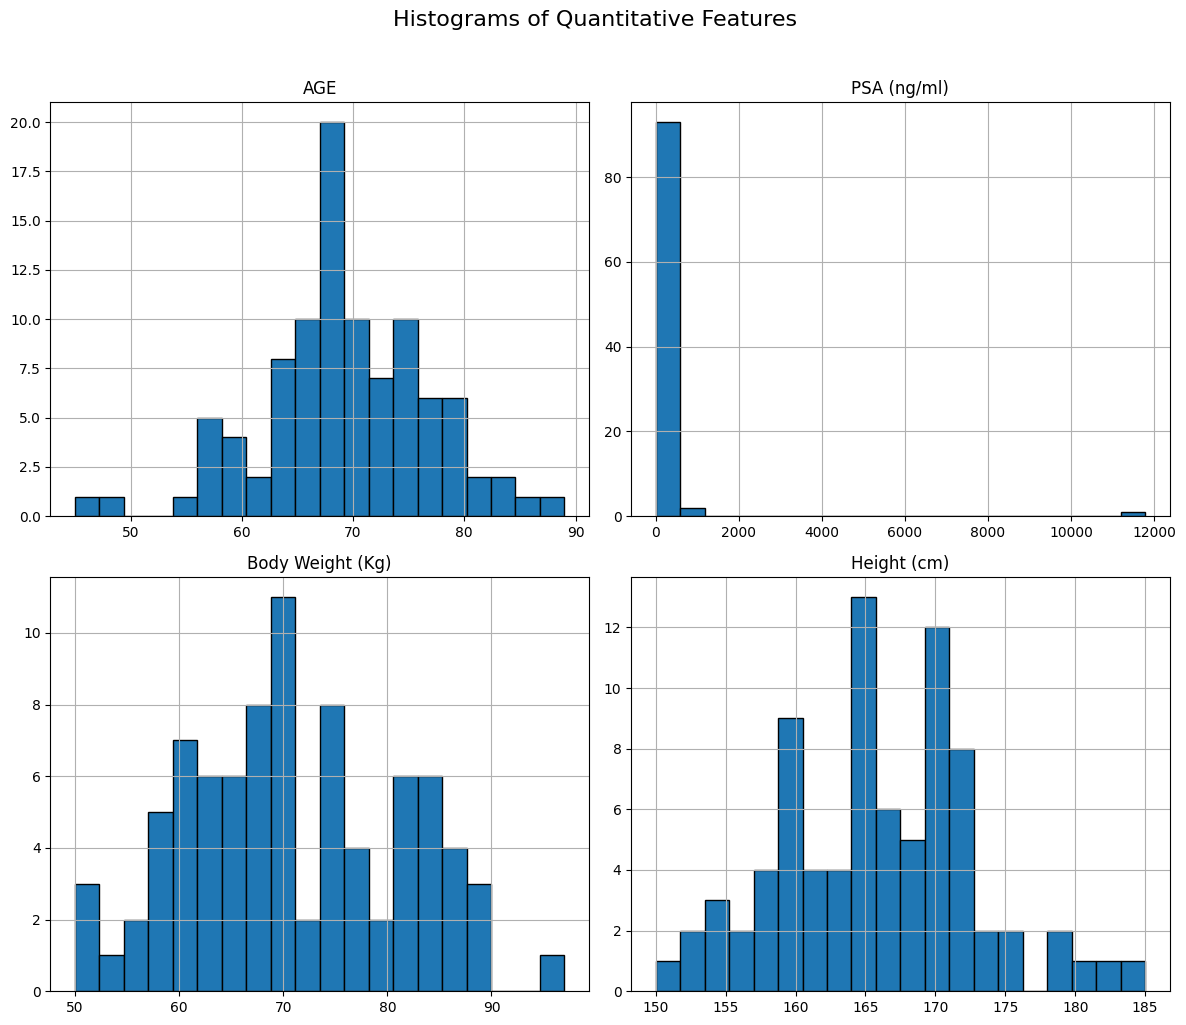

In [12]:
import matplotlib.pyplot as plt

quantitative.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle("Histograms of Quantitative Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

For the quantitative values, the 'AGE', 'Body Weight (Kg)' and 'Height (cm)' columns are normally distributed. However the PSA values shows a quite a few abnormal values that extends far right.

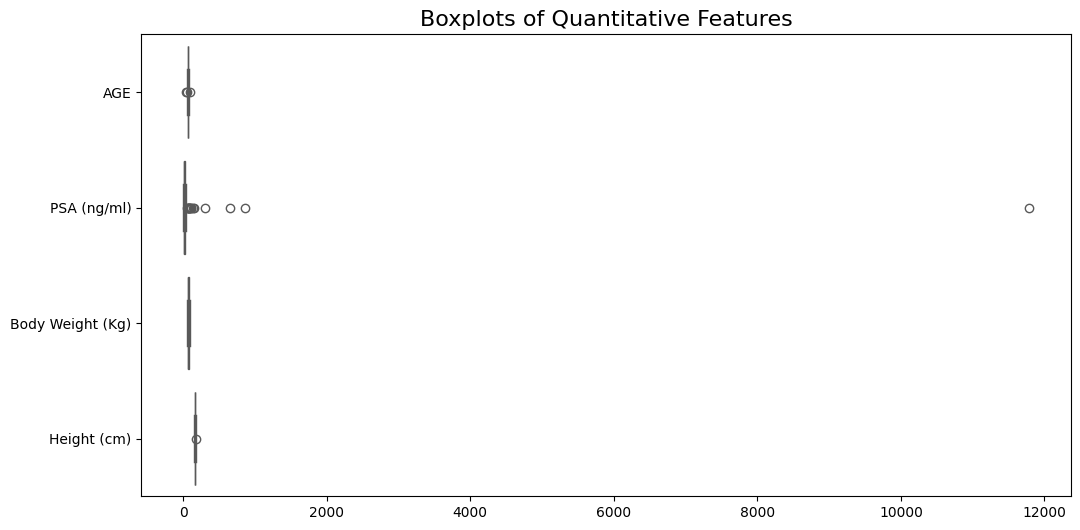

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=quantitative, orient="h", palette="Set2")
plt.title("Boxplots of Quantitative Features", fontsize=16)
plt.show()


Focusing specifically on PSA, we can see that there are a few data points that lies at a distance from the box, indicating that it is significantly different from the majority of the data distribution, or in other words, outliers. Based on expert opinions, the values for PSA indeed may vary, however the diagnostic will be to check if the PSA value exceeds 4 ng/ml. Moreover, based on this source https://www.mdanderson.org/cancerwise/prostate-specific-antigen--psa--levels-by-age--what-to-know.h00-159695967.html, it mentions that there is no upper limit to the PSA level. Nevertheless, since our dataset is relatively small, such an extreme value might distort our prediction capabilities, and therefore, it is best to treat these as an outlier by removing those with PSA >= 200 ng/ml (a reasonable value considering that majority of values are within this range).

Next, we will move on to the qualitative data, plotting them on a simple bar chart:

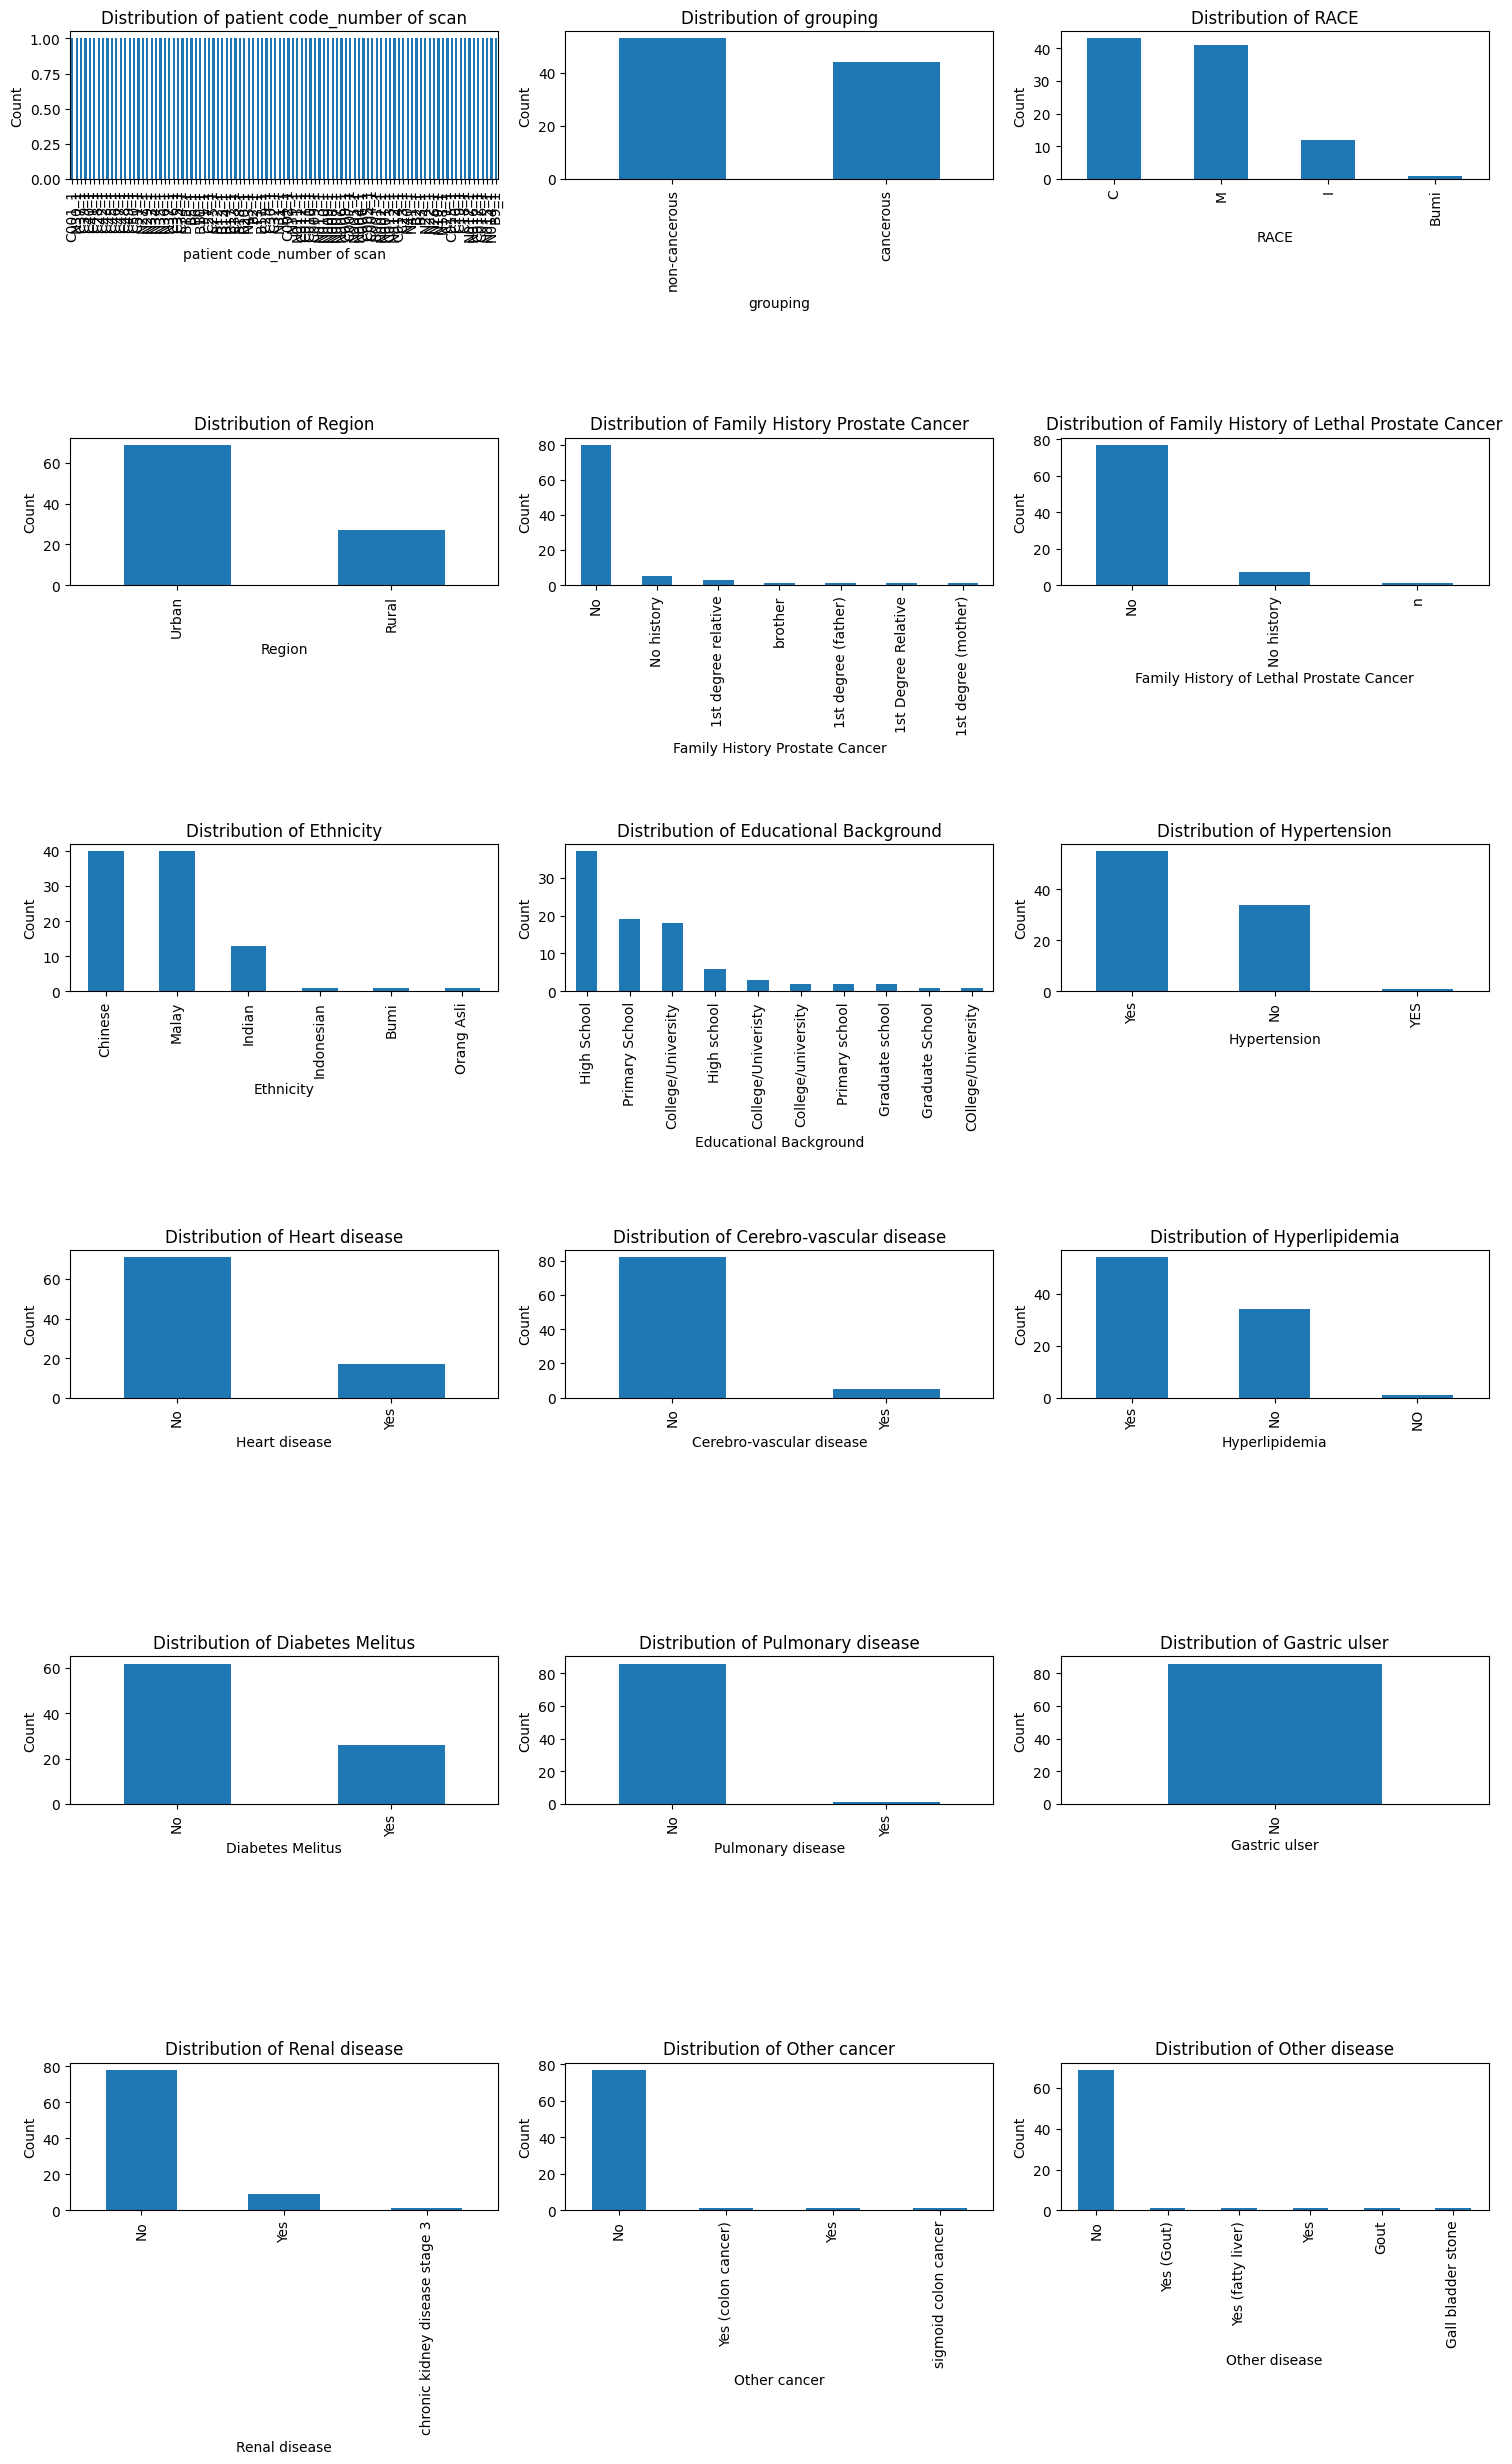

In [14]:
import matplotlib.pyplot as plt
import math

n = len(qualitative)
rows = math.ceil(n / 3)
fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))

for i, col in enumerate(qualitative):
    r, c = divmod(i, 3)
    ax = axes[r, c] if rows > 1 else axes[c]
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_ylabel("Count")

for j in range(i + 1, rows * 3):
    r, c = divmod(j, 3)
    fig.delaxes(axes[r, c] if rows > 1 else axes[c])

plt.tight_layout()
plt.show()


Looking at the bar charts above, we can make the following observations:

1. The target variable, which is the 'Distribution of grouping' is slightly imbalanced, with the cancerous patients count being slightly less than the non-cancerous patient counts, which may be a source of bias later on. In the case that this imbalanced problem cannot be solved, we need to utilise a metrics that can best comprehend this situation such as ROC-AUC https://www.geeksforgeeks.org/machine-learning/auc-roc-curve/ .

2. As for the distribution of race, it is also imbalanced, with C and M values dominating the majority of the samples, followed by around 10 samples for I, and Bumi with only a few data samples. Further processing strategies such as imputation or maybe aggregation might be needed to ensure fairness of the machine learning model prediction. Furthermore, racial discrimination check must be performed afterwards, using fairness checking framework such as Fairlearn https://fairlearn.org .

3. Distribution of region is also imbalanced, with urban area having more share in the data compared to rural areas. However, this might be explanaible as rural areas might have less resources to obtain their medical needs as compared to their counterparts. 

4. As for the distribution of family history prostate cancer, it is crucial to note the domain of values available, which are 'No', 'No history', '1st degree relative', 'brother', '1st degree (father)', '1st Degree Relative', and '1st degree (mother)'. This shows a naming inconsistencies, and possible definition overlapping within the values (e.g. brother and 1st degree relative). Further clarification is needed to resolve this issue.

5. Distribution of Family History of Lethal Prostate Cancer also shows a discrepancy in values, with the value No and n probabily pointing towards the same semantic meaning.

6. Distribution of Ethnicity faces the same issue as the distribution of race. However a more significant problem in hand is that both race and ethnicity might overlap or be strongly correlated and introduce multicollinearity. We could test this using Cramer's V test, which measures how strong the association is between the two given values on a scale of 0 to 1.

7. As for the distribution of educational background, it is easy to notice that there is again, some inconsistencies in the value namings, causing the same values to be identified differently. A standardized naming convention should be introduced to all data within the dataset to fix similar issues.

8. Naming convention inconsistency is again introduced for distribution of hypertension, hyperlipidemia.

9. All patients within the dataset have no gastric ulcer (which feature name has a typo - gastric ulser). Therefore this feature should be removed as it brings no predictive power due to the nature of the data.

10. Chronic kidney disease stage 3 is categorized as a class in 'Distribution of Renal disease', with the remaining classes being 'Yes' and 'No'. It is unclear whether this assignment was intentional or not, therefore further clarification will be required before further action on this feature. The same situation goes to both distributions of other cancer and other diseases, where there exists class name consisting of Yes, but followed by the specific condition of the patient. 

#### Multivariate Feature Analysis

/var/folders/mg/p_ksvly91lbfq3r067sbdvvw0000gn/T/ipykernel_50628/611889665.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
/var/folders/mg/p_ksvly91lbfq3r067sbdvvw0000gn/T/ipykernel_50628/611889665.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
/var/folders/mg/p_ksvly91lbfq3r067sbdvvw0000gn/T/ipykernel_50628/611889665.py:14: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
/var/folders/mg/p_ksvly91lbfq3r067sbdvvw0000gn/T/ipykernel_50628/611889665.py:14: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
/var/folders/mg/p_ksvly91lbfq3r067sbdvvw0000gn/T/ipykernel_50628/611889665.py:14: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
/var/folders/mg/p_

                                          patient code_number of scan  \
patient code_number of scan                                       inf   
grouping                                                          inf   
RACE                                                              NaN   
Region                                                            NaN   
Family History Prostate Cancer                                    NaN   
Family History of Lethal Prostate Cancer                          inf   
Ethnicity                                                         NaN   
Educational Background                                            NaN   
Hypertension                                                      NaN   
Heart disease                                                     inf   
Cerebro-vascular disease                                          inf   
Hyperlipidemia                                                    NaN   
Diabetes Melitus                                   

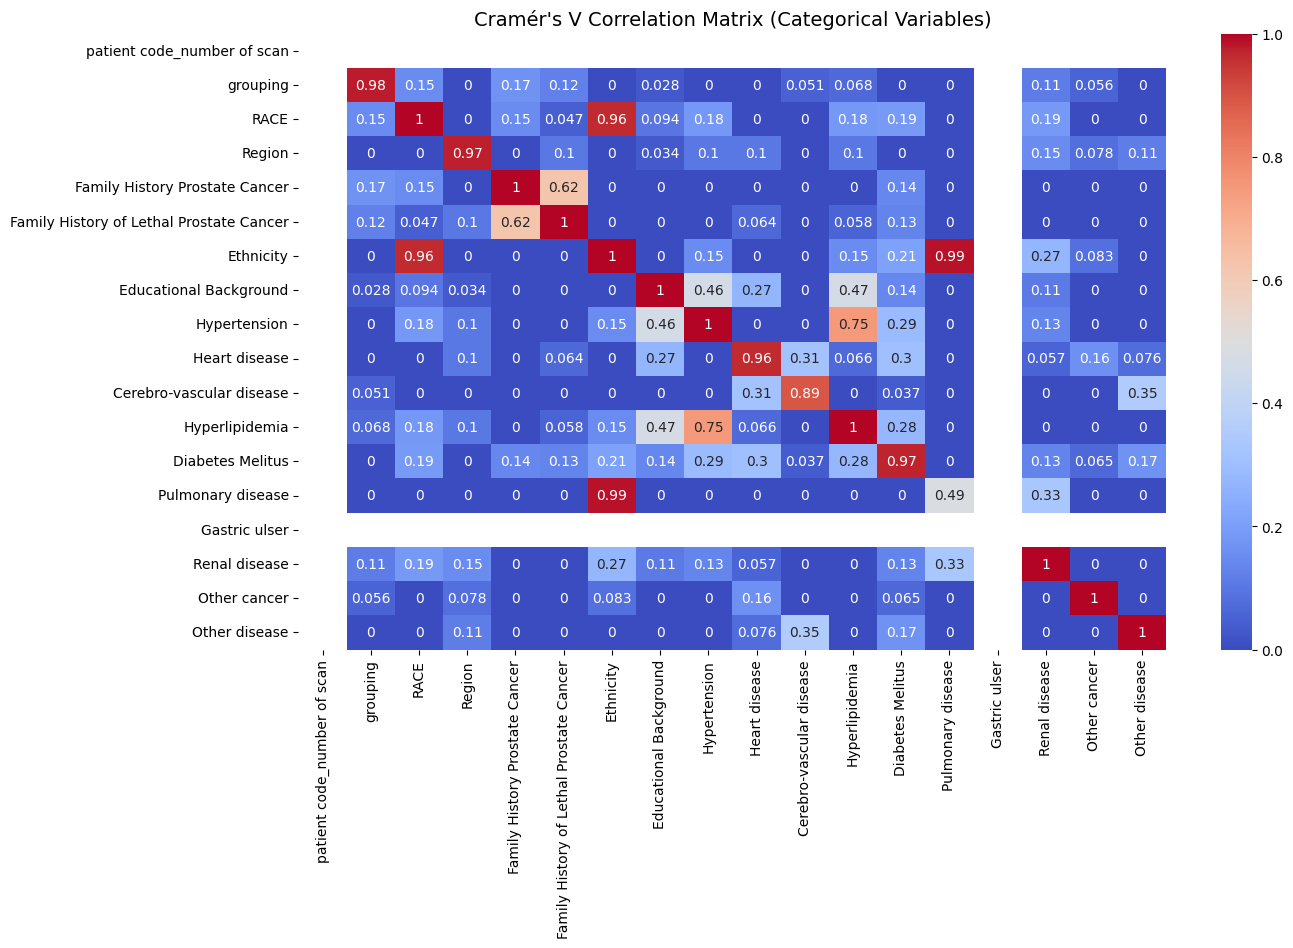

In [15]:
import pandas as pd
import numpy as np
import scipy.stats as ss

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cramers_results = pd.DataFrame(np.zeros((len(qualitative.columns), len(qualitative.columns))),
                               index=qualitative.columns, columns=qualitative.columns)

for col1 in qualitative.columns:
    for col2 in qualitative.columns:
        cramers_results.loc[col1, col2] = cramers_v(df[col1], df[col2])

print(cramers_results.round(2))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
sns.heatmap(cramers_results, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Cramér's V Correlation Matrix (Categorical Variables)", fontsize=14)
plt.show()

From the Cramer's V matrix above, we can make the observations below:

1. Ethnicity have a strong correlation with the race. This is expected since the two values are closely related, therefore overlaps heavily. The overlapping suggests that the variables may not provide fully independent information, and therefore will be a source of multicollinearity. Depending on further exploration, one of them must need to be removed to avoid bias and overfitting.

2. Family history prostate cancer and family history of lethal prostate cancer have quite a strong correlation of 0.62. This also is fairly reasonable, considering that individuals with a family history of prostate cancer are naturally more likely to also report cases where the disease was lethal. In other words, 'Family history of lethal prostate cancer' is a subset of 'Family history prostate cancer'. Thus one of the variables might need to be removed later on unless there is a strong clinical reason not to do so.

3. It is also noted that ethnicity is very strongly correlated with 'Pulmonary disease'. However the high correlation value of 0.99 is rather peculiar. Further exploration is required to confirm this observation.

In [16]:
df['Pulmonary disease'].value_counts()

Pulmonary disease
No     86
Yes     1
Name: count, dtype: int64

We can see that only one of the patient have pulmonary disease, which means that the variable is highly imbalanced, therefore the correlation is being driven by a single case rather than a meaningful pattern. A simple solution might be to drop the variable, since it provides almost no statistical signal. 

4. We can also see that hyperlipidemia and hypertension has a strong association of 0.75, suggesting that they may be related to one another. This is clinically reasonable, as both are common cardiovascular risk factors, as opposed to redundancy or data quality issues.

5. Looking at the target row, we can observe that race, family history of prostate cancer, family history of lethal prostate cancer, as well as renal disease are the most correlated variables to prostate cancer prediction.

6. Gastric ulcer is not shown on the matrix, probably indicating a problem with less than two valid categories.

In [17]:
df['Gastric ulser'].unique()

array(['No', nan], dtype=object)

Since this column only has one valid unique value, it must be discarded later on.

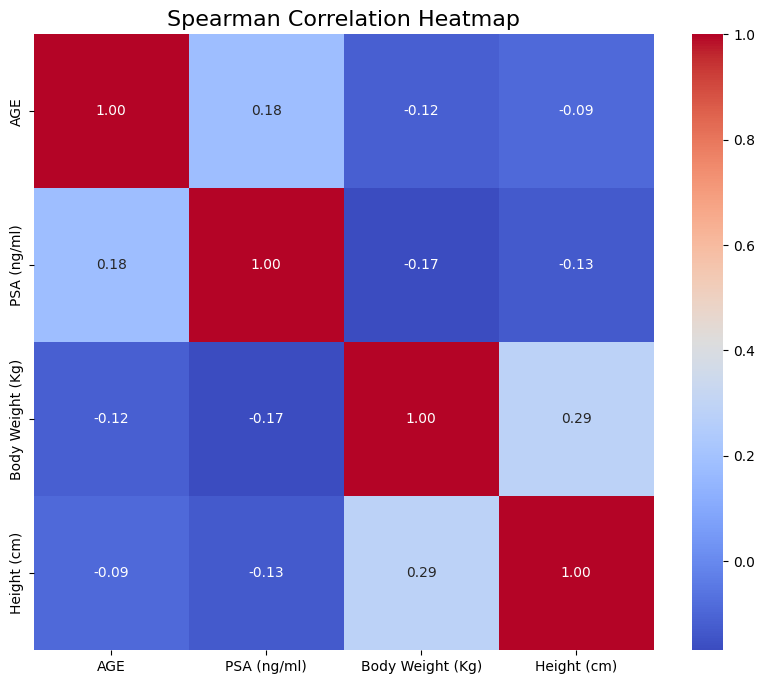

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

spearman_corr = df[quantitative.columns].corr(method='spearman')

# plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap", fontsize=16)
plt.show()


From the Spearman's correlation plot above, we see that the variables shows weak association to one another, with the highest correlation value being 0.29 (which is still weak) between body weight and height. Given that we currently only have four quantitative variables, the limited strength of correlation suggests that these features are independently important and may contribute unique information to the analysis.

#### Preprocessing

Before we start transforming the variables, it might be easier to standardize the variable naming, such as using snake_case, for easier reference later on.

In [19]:
import pandas as pd
import re

def to_snake_case(name):
    # Replace spaces and hyphens with underscores
    name = re.sub(r"[\s\-]+", "_", name)
    
    # Convert camelCase or PascalCase to snake_case
    name = re.sub(r"([A-Z]+)([A-Z][a-z])", r'\1_\2', name)
    name = re.sub(r"([a-z\d])([A-Z])", r'\1_\2', name)
     
    # Lowercase
    return name.lower()

df.columns = [to_snake_case(col) for col in df.columns]

print(df.columns)


Index(['patient_code_number_of_scan', 'grouping', 'age', 'race', 'psa_(ng/ml)',
       'body_weight_(kg)', 'height_(cm)', 'region',
       'family_history_prostate_cancer',
       'family_history_of_lethal_prostate_cancer', 'ethnicity',
       'educational_background', 'hypertension', 'heart_disease',
       'cerebro_vascular_disease', 'hyperlipidemia', 'diabetes_melitus',
       'pulmonary_disease', 'gastric_ulser', 'renal_disease', 'other_cancer',
       'other_disease'],
      dtype='object')


We need to remove the patient code number of scan column, as it is not useful here.

In [20]:
df = df.drop('patient_code_number_of_scan', axis=1)

To avoid introducing noises, we will remove rows/entries with at least 50% (0.5 threshold) missing values, as imputing them would introduce more uncertainty to the overall dataset. It is debatable to use a less stricter threshold of 0.3, however since we have limited amount of data to work with, we won't resort to this unless it is certain that the missing data itself contain important clinical outcomes.

In [21]:
import pandas as pd

def check_missing_rows(df, threshold=0.3):

    missing_frac = df.isnull().mean(axis=1)
    flagged = missing_frac >= threshold
    return pd.DataFrame({'missing_frac': missing_frac, 'flagged': flagged})

result = check_missing_rows(df, threshold=0.5)
flagged_rows = result[result['flagged']]
print(flagged_rows)

    missing_frac  flagged
64      0.761905     True


In [22]:
rows_to_drop = flagged_rows.index
df = df.drop(rows_to_drop)

We will also drop the rows with PSA outliers found in EDA:

In [23]:
df = df[df['psa_(ng/ml)'] < 200]

We also need to drop one column from race and ethnicity as both are highly correlated. It will also be much easier to decide which to drop based on the number of missing columns present.

In [24]:
df.isna().sum()

grouping                                     0
age                                          0
race                                         0
psa_(ng/ml)                                  0
body_weight_(kg)                             9
height_(cm)                                 12
region                                       0
family_history_prostate_cancer               3
family_history_of_lethal_prostate_cancer    10
ethnicity                                    1
educational_background                       4
hypertension                                 6
heart_disease                                8
cerebro_vascular_disease                     9
hyperlipidemia                               7
diabetes_melitus                             8
pulmonary_disease                            9
gastric_ulser                                9
renal_disease                                8
other_cancer                                16
other_disease                               21
dtype: int64

Let's have a look at the missing value count for each column:

In [25]:
print(f"Race missing count: {df['race'].isna().sum()}")
print(f"Ethnicity missing count: {df['ethnicity'].isna().sum()}")

Race missing count: 0
Ethnicity missing count: 1


In [26]:
df = df.drop('ethnicity', axis=1)

Lastly, we also need to remove the pulmonary disease column, as only one entry contains a different value from the rest, therefore it provides no predictive power. The same goes to the 'gastric_ulser' column with only one valid category.

In [27]:
df = df.drop(['pulmonary_disease', 'gastric_ulser'], axis=1)

In [28]:
df.head()

,grouping,age,race,psa_(ng/ml),body_weight_(kg),height_(cm),region,family_history_prostate_cancer,family_history_of_lethal_prostate_cancer,educational_background,hypertension,heart_disease,cerebro_vascular_disease,hyperlipidemia,diabetes_melitus,renal_disease,other_cancer,other_disease
0,cancerous,68,C,7.92,71.0,172.0,Rural,1st degree relative,No,College/University,Yes,No,No,Yes,No,No,No,No
1,cancerous,57,C,10.00,68.0,175.0,Urban,No history,No history,High School,No,No,No,No,No,No,No,No
2,non-cancerous,82,C,1.09,69.0,170.0,Urban,No,No,High School,Yes,No,No,Yes,No,No,No,No
3,non-cancerous,60,C,8.98,76.0,157.0,Urban,No,No,High School,No,No,No,No,No,NaN,Yes (colon cancer),No
4,non-cancerous,74,M,5.30,59.0,160.0,Urban,No,No,High School,Yes,NaN,NaN,NaN,Yes,Yes,NaN,NaN


In [29]:
df.isna().sum()

grouping                                     0
age                                          0
race                                         0
psa_(ng/ml)                                  0
body_weight_(kg)                             9
height_(cm)                                 12
region                                       0
family_history_prostate_cancer               3
family_history_of_lethal_prostate_cancer    10
educational_background                       4
hypertension                                 6
heart_disease                                8
cerebro_vascular_disease                     9
hyperlipidemia                               7
diabetes_melitus                             8
renal_disease                                8
other_cancer                                16
other_disease                               21
dtype: int64

Next, we will go through each columns individually to identify the transformation required. Again, we will separate the variables into qualitative and quantitative columns.


In [30]:
numerical = ['float64', 'int64']

quantitative = df.select_dtypes(include=numerical)
qualitative = df.select_dtypes(exclude=numerical)

print(f"Qualitative: {qualitative.columns}")
print(f"Quantitative: {quantitative.columns}")

Qualitative: Index(['grouping', 'race', 'region', 'family_history_prostate_cancer',
       'family_history_of_lethal_prostate_cancer', 'educational_background',
       'hypertension', 'heart_disease', 'cerebro_vascular_disease',
       'hyperlipidemia', 'diabetes_melitus', 'renal_disease', 'other_cancer',
       'other_disease'],
      dtype='object')
Quantitative: Index(['age', 'psa_(ng/ml)', 'body_weight_(kg)', 'height_(cm)'], dtype='object')


Before moving on to imputation, we first need to clean the existing data values to ensure that the imputed value are valid.

In [31]:
for col in qualitative.columns:
    types_in_col = df[col].map(type).unique()
    if len(types_in_col) > 1:
        print(f"Column '{col}' has multiple types: {types_in_col}")
        print(f"---Values are {df[col].unique()}")

Column 'family_history_prostate_cancer' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['1st degree relative' 'No history' 'No' nan '1st degree (father)'
 '1st Degree Relative' '1st degree (mother)']
Column 'family_history_of_lethal_prostate_cancer' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['No' 'No history' nan 'n']
Column 'educational_background' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['College/University' 'High School' 'Primary School' 'College/university'
 'Primary school' nan 'High school' 'Graduate School' 'College/Univeristy'
 'Graduate school' 'COllege/University']
Column 'hypertension' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['Yes' 'No' nan 'YES']
Column 'heart_disease' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['No' nan 'Yes']
Column 'cerebro_vascular_disease' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['No' nan 'Yes']
Column 'hyperli

From above we can notice quite a lot of naming inconsistencies present. We will fix them one by one.

In [32]:
df['family_history_prostate_cancer'].value_counts()

family_history_prostate_cancer
No                     78
No history              4
1st degree relative     3
1st degree (father)     1
1st Degree Relative     1
1st degree (mother)     1
Name: count, dtype: int64

The majority of values in this column are "No," followed by "No history" (likely equivalent to N/A), with the remaining values indicating a first-degree relative affected. Since there are multiple entries referring to first-degree relatives, we aggregate them under a single category, "Yes," to simplify analysis and reduce sparsity.

In [33]:
df['family_history_prostate_cancer'] = df['family_history_prostate_cancer'].replace(
    {
        '1st degree (father)': 'Yes',
        '1st Degree Relative': 'Yes',
        '1st degree (mother)': 'Yes',
        '1st degree relative': 'Yes',
        'No history': 'No',
    }
)

In [34]:
df['family_history_prostate_cancer'].value_counts()

family_history_prostate_cancer
No     82
Yes     6
Name: count, dtype: int64

In [35]:
df['family_history_of_lethal_prostate_cancer'].value_counts()

family_history_of_lethal_prostate_cancer
No            74
No history     6
n              1
Name: count, dtype: int64

As all possible values are seemly related to no, therefore this attribute only has one categorical value, and should be discarded.

In [36]:
df = df.drop('family_history_of_lethal_prostate_cancer', axis=1)

In [37]:
df['educational_background'].value_counts()

educational_background
High School           37
College/University    18
Primary School        16
High school            6
College/university     2
Primary school         2
College/Univeristy     2
Graduate school        2
Graduate School        1
COllege/University     1
Name: count, dtype: int64

In [38]:
df['educational_background'] = df['educational_background'].replace(
    {
        'College/university': 'College/University',
        'COllege/University': 'College/University',
        'College/Univeristy': 'College/University',
        'Graduate school': 'Graduate School',
        'High school': 'High School',
        'Primary school': 'Primary School'
    }
)

In [39]:
df['educational_background'].value_counts()

educational_background
High School           43
College/University    23
Primary School        18
Graduate School        3
Name: count, dtype: int64

In [40]:
df['hypertension'].value_counts()

hypertension
Yes    55
No     29
YES     1
Name: count, dtype: int64

In [41]:
df.loc[df['hypertension'] == 'YES', 'hypertension'] = 'Yes'

In [42]:
df['hyperlipidemia'].value_counts()

hyperlipidemia
Yes    52
No     31
NO      1
Name: count, dtype: int64

In [43]:
df.loc[df['hyperlipidemia'] == 'NO', 'hyperlipidemia'] = 'No'

In [44]:
df['renal_disease'].value_counts()

renal_disease
No                                73
Yes                                9
chronic kidney disease stage 3     1
Name: count, dtype: int64

In this case, the value 'chronic kidney disease stage 3' should be classified under 'Yes', since it is rather specific for this column.

In [45]:
df.loc[df['renal_disease'] == 'chronic kidney disease stage 3', 'renal_disease'] = 'Yes'

In [46]:
df['other_cancer'].value_counts()

other_cancer
No                      72
Yes (colon cancer)       1
Yes                      1
sigmoid colon cancer     1
Name: count, dtype: int64

In [47]:
df.loc[
    (df['other_cancer'] == 'Yes (colon cancer)') | (df['other_cancer'] == 'sigmoid colon cancer'),
    'other_cancer'
] = 'Yes'

In [48]:
df['other_disease'].value_counts()

other_disease
No                    65
Yes (Gout)             1
Yes (fatty liver)      1
Yes                    1
Gout                   1
Gall bladder stone     1
Name: count, dtype: int64

In [49]:
df.loc[
    (df['other_disease'] == 'Yes (Gout)') | (df['other_disease'] == 'Yes (fatty liver)') | (df['other_disease'] == 'Gout') | (df['other_disease'] == 'Gall bladder stone'),
    'other_disease'
] = 'Yes'

In [50]:
numerical = ['float64', 'int64']

quantitative = df.select_dtypes(include=numerical)
qualitative = df.select_dtypes(exclude=numerical)

print(f"Qualitative: {qualitative.columns}")
print(f"Quantitative: {quantitative.columns}")

Qualitative: Index(['grouping', 'race', 'region', 'family_history_prostate_cancer',
       'educational_background', 'hypertension', 'heart_disease',
       'cerebro_vascular_disease', 'hyperlipidemia', 'diabetes_melitus',
       'renal_disease', 'other_cancer', 'other_disease'],
      dtype='object')
Quantitative: Index(['age', 'psa_(ng/ml)', 'body_weight_(kg)', 'height_(cm)'], dtype='object')


In [51]:
for col in qualitative.columns:
    types_in_col = df[col].map(type).unique()
    if len(types_in_col) > 1:
        print(f"Column '{col}' has multiple types: {types_in_col}")
        print(f"---Values are {df[col].unique()}")

Column 'family_history_prostate_cancer' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['Yes' 'No' nan]
Column 'educational_background' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['College/University' 'High School' 'Primary School' nan 'Graduate School']
Column 'hypertension' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['Yes' 'No' nan]
Column 'heart_disease' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['No' nan 'Yes']
Column 'cerebro_vascular_disease' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['No' nan 'Yes']
Column 'hyperlipidemia' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['Yes' 'No' nan]
Column 'diabetes_melitus' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['No' 'Yes' nan]
Column 'renal_disease' has multiple types: [<class 'str'> <class 'float'>]
---Values are ['No' nan 'Yes']
Column 'other_cancer' has multiple types: [<class 'st

For the imputation, we will used a well-established imputation method, known as missForest, due to its capability to model complex interactions between features, both categorical and continuous, at the same time to predict missing values.


Further info at: https://bmcmedresmethodol.biomedcentral.com/articles/10.1186/s12874-024-02392-2

In [52]:
from missforest import MissForest
from sklearn.preprocessing import FunctionTransformer
import pandas as pd

def missforest_imputer(X):
    imputer = MissForest()
    X_imputed = imputer.fit_transform(X)
    return pd.DataFrame(X_imputed, columns=X.columns)

missforest_transformer = FunctionTransformer(missforest_imputer)

Before applying missForest, it is crucial to ensure that each column will only have one data type value, and that the values are cleaned to avoid inconsistencies, specifically on the qualitative variables, as object data types may have different subtypes. 

In [53]:
df.isna().sum()

grouping                           0
age                                0
race                               0
psa_(ng/ml)                        0
body_weight_(kg)                   9
height_(cm)                       12
region                             0
family_history_prostate_cancer     3
educational_background             4
hypertension                       6
heart_disease                      8
cerebro_vascular_disease           9
hyperlipidemia                     7
diabetes_melitus                   8
renal_disease                      8
other_cancer                      16
other_disease                     21
dtype: int64

Checking the imputed version:

In [54]:
import pandas as pd
import numpy as np
from missforest import MissForest

qual_cols = [
    'family_history_prostate_cancer', 'educational_background', 'hypertension',
    'heart_disease', 'cerebro_vascular_disease', 'hyperlipidemia',
    'diabetes_melitus', 'renal_disease', 'other_cancer', 'other_disease'
]

non_valid = ['grouping', 'race', 'region'] # Avoid modifying these values as they will introduce bias
target_col = "grouping"
feature_cols = [col for col in df.columns if col not in non_valid]

mapping_dict = {
    'family_history_prostate_cancer': {'No': 0, 'Yes': 1},
    'educational_background': {'Primary School': 0, 'High School': 1, 'College/University': 2, 'Graduate School': 3},
    'hypertension': {'No': 0, 'Yes': 1},
    'heart_disease': {'No': 0, 'Yes': 1},
    'cerebro_vascular_disease': {'No': 0, 'Yes': 1},
    'hyperlipidemia': {'No': 0, 'Yes': 1},
    'diabetes_melitus': {'No': 0, 'Yes': 1},
    'renal_disease': {'No': 0, 'Yes': 1},
    'other_cancer': {'No': 0, 'Yes': 1},
    'other_disease': {'No': 0, 'Yes': 1},
}

inverse_mapping_dict = {col: {v: k for k, v in mapping.items()} for col, mapping in mapping_dict.items()}

# Map strings to numbers for MissForest
for col in feature_cols:
    if col in mapping_dict:
        df[col] = df[col].map(mapping_dict[col])

# Specify categorical columns for MissForest (exclude target)
categorical_features = [col for col in qual_cols if col in feature_cols]
print(categorical_features)
mf = MissForest(categorical=categorical_features)

# Impute
df_imputed_features = mf.fit_transform(df[feature_cols])

# Convert back to DataFrame
df_imputed_features = pd.DataFrame(df_imputed_features, columns=feature_cols)

# Combine target back
df_imputed = pd.concat([df_imputed_features], axis=1)

df_non_valid = df[non_valid]

# Combine with imputed features + target
df_final = pd.concat([df_imputed, df_non_valid], axis=1)

# Optional: reorder columns if needed
df_final = df_final[df.columns]  # Keep the original column order

print(df_final.head())

['family_history_prostate_cancer', 'educational_background', 'hypertension', 'heart_disease', 'cerebro_vascular_disease', 'hyperlipidemia', 'diabetes_melitus', 'renal_disease', 'other_cancer', 'other_disease']


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/missforest/missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
100%|██████████| 5/5 [00:05<00:00,  1.12s/it]
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/missforest/missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/missforest/missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use 

        grouping  age race  psa_(ng/ml)  body_weight_(kg)  height_(cm) region  \
0      cancerous   68    C         7.92              71.0        172.0  Rural   
1      cancerous   57    C        10.00              68.0        175.0  Urban   
2  non-cancerous   82    C         1.09              69.0        170.0  Urban   
3  non-cancerous   60    C         8.98              76.0        157.0  Urban   
4  non-cancerous   74    M         5.30              59.0        160.0  Urban   

   family_history_prostate_cancer  educational_background  hypertension  \
0                             1.0                     2.0           1.0   
1                             0.0                     1.0           0.0   
2                             0.0                     1.0           1.0   
3                             0.0                     1.0           0.0   
4                             0.0                     1.0           1.0   

   heart_disease  cerebro_vascular_disease  hyperlipidemia  di

One hot encoding to add back the region and race values:

In [55]:
from sklearn.preprocessing import OneHotEncoder

ohe_cols = ['race', 'region']

ohe = OneHotEncoder(sparse_output=False)

ohe_array = ohe.fit_transform(df_final[ohe_cols])
ohe_feature_names = ohe.get_feature_names_out(ohe_cols)

df_ohe = pd.DataFrame(ohe_array, columns=ohe_feature_names, index=df_final.index)

df_final = pd.concat([df_final.drop(columns=ohe_cols), df_ohe], axis=1)


In [56]:
df_final.isna().sum()

grouping                          0
age                               0
psa_(ng/ml)                       0
body_weight_(kg)                  0
height_(cm)                       0
family_history_prostate_cancer    0
educational_background            0
hypertension                      0
heart_disease                     0
cerebro_vascular_disease          0
hyperlipidemia                    0
diabetes_melitus                  0
renal_disease                     0
other_cancer                      0
other_disease                     0
race_C                            0
race_I                            0
race_M                            0
region_Rural                      0
region_Urban                      0
dtype: int64

It is also important to label encode the target variable, grouping.

In [57]:
df_final['grouping'] = df_final['grouping'].map({
    'cancerous': 1,
    'non-cancerous': 0
})

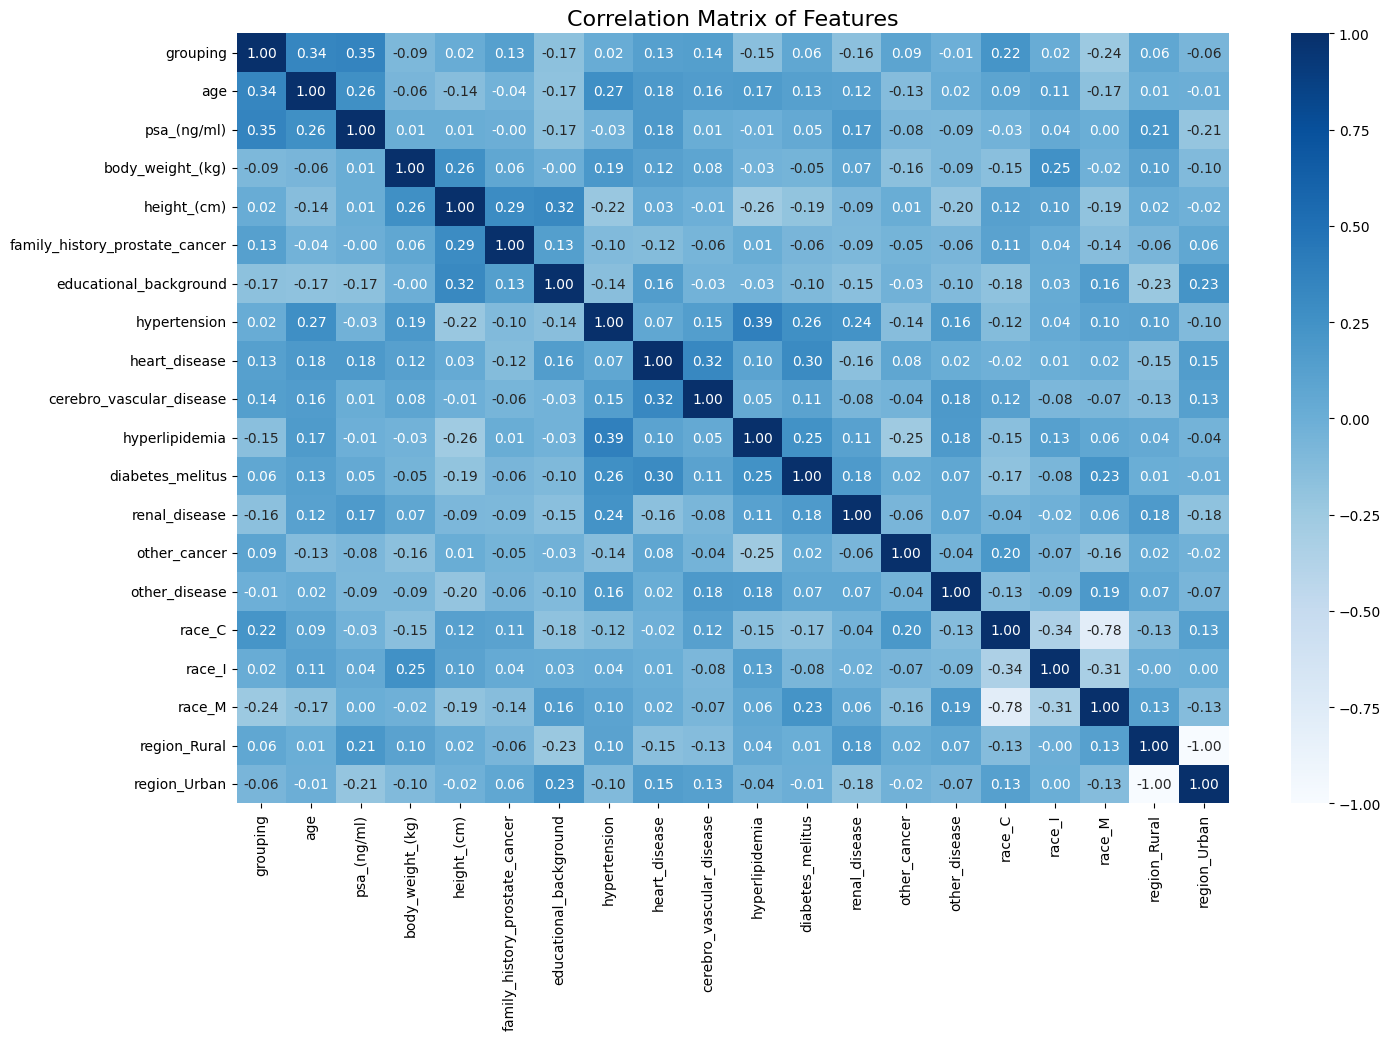

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_final.corr()

plt.figure(figsize=(16, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,       
    fmt=".2f",        
    cmap='Blues',    
    center=0
)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()


Since region rural and region urban are negatively strongly correlated to each other, we will remove one of them to avoid multicollinearity.

In [59]:
df_final = df_final.drop('region_Urban', axis=1)

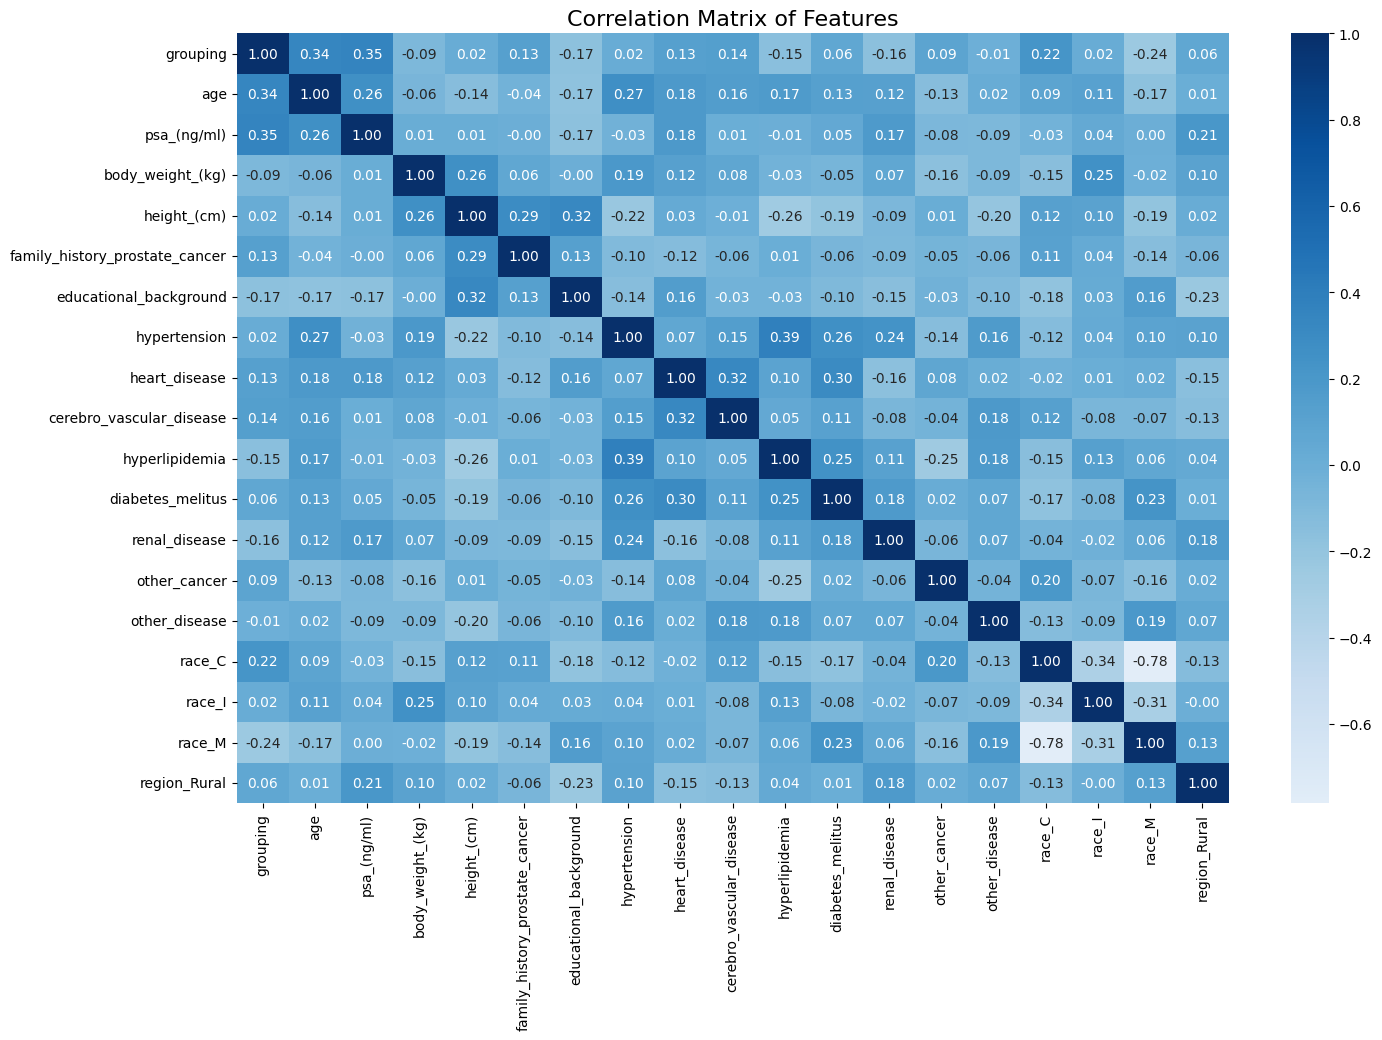

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_final.corr()

plt.figure(figsize=(16, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,       
    fmt=".2f",        
    cmap='Blues',    
    center=0
)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()


There are a few things to notice:

1. race_C is positively correlated to grouping (0.22), whereas race_M is negatively correlated to grouping (-0.24).

In [61]:
df_final[df_final['grouping'] == 1]['race_C'].value_counts()

race_C
1.0    23
0.0    16
Name: count, dtype: int64

In [62]:
df_final[df_final['grouping'] == 1]['race_M'].value_counts()

race_M
0.0    28
1.0    11
Name: count, dtype: int64

From the result above, we can see that most Chinese (race_C) patients have positive case of prostate cancer, wheras most Malays (race_M) have negative case of prostate cancer. This might be attributed to differences in genetic predisposition, lifestyle factors, or screening patterns between the two populations. However, it’s important to note that the observed correlation could also be influenced by the relative sample sizes of each group and should not be interpreted as a causal relationship without further epidemiological investigation.

2. Age and psa values are among the most strongly positively correlated factors to grouping (target variable). This means as age and psa values increase, the risk of prostate cancer to be positive increases.
3. Family history of prostate cancer, heart disease and cerebro vascular disease are weakly positively correlated to grouping, whereas educational background, hyperlipidemia and renal disease are weakly negatively correlated to grouping.

In [63]:
df_final.head()

,grouping,age,psa_(ng/ml),body_weight_(kg),height_(cm),family_history_prostate_cancer,educational_background,hypertension,heart_disease,cerebro_vascular_disease,hyperlipidemia,diabetes_melitus,renal_disease,other_cancer,other_disease,race_C,race_I,race_M,region_Rural
0,1,68,7.92,71.0,172.0,1.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1,57,10.00,68.0,175.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0,82,1.09,69.0,170.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0,60,8.98,76.0,157.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,74,5.30,59.0,160.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


The dataframe is now complete.

### Modelling

In [64]:
df_final.grouping.value_counts()

grouping
0    52
1    39
Name: count, dtype: int64

As the target class distribution is imbalanced, we can perform SMOTE to upsample the minority class (cancerous) later.

In [65]:
df_final.head()

,grouping,age,psa_(ng/ml),body_weight_(kg),height_(cm),family_history_prostate_cancer,educational_background,hypertension,heart_disease,cerebro_vascular_disease,hyperlipidemia,diabetes_melitus,renal_disease,other_cancer,other_disease,race_C,race_I,race_M,region_Rural
0,1,68,7.92,71.0,172.0,1.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1,57,10.00,68.0,175.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0,82,1.09,69.0,170.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0,60,8.98,76.0,157.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,74,5.30,59.0,160.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [66]:
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=['grouping'])  
y = df_final['grouping']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [67]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [68]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(random_state=42)
model.fit(X_train_res, y_train_res)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [69]:
import optuna

from sklearn.metrics import roc_auc_score
from optuna.samplers import TPESampler

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1
    }

    model = LGBMClassifier(**param)
    model.fit(X_train_res, y_train_res)
    y_prob = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    return auc  

sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=100)  

print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

best_params = study.best_params
best_model = LGBMClassifier(**best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train_res, y_train_res)

from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

[I 2026-03-26 13:45:56,447] A new study created in memory with name: no-name-4a1ffd4d-6b4c-4ffe-a3c5-99d305e3f10d
[I 2026-03-26 13:45:56,666] Trial 0 finished with value: 0.6363636363636364 and parameters: {'n_estimators': 437, 'max_depth': 12, 'num_leaves': 115, 'learning_rate': 0.07661100707771368, 'min_child_samples': 19, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469887, 'reg_lambda': 0.002570603566117596}. Best is trial 0 with value: 0.6363636363636364.
[I 2026-03-26 13:45:57,010] Trial 1 finished with value: 0.5909090909090909 and parameters: {'n_estimators': 737, 'max_depth': 3, 'num_leaves': 147, 'learning_rate': 0.1696753360719655, 'min_child_samples': 25, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 5.472429642032189e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 0 with value: 0.6363636363636364.
[I 2026-03-26 13:45:57,081] Trial 2 finished with value: 0.7102272727272727 and

Best AUC: 0.7727272727272727
Best params: {'n_estimators': 652, 'max_depth': 6, 'num_leaves': 75, 'learning_rate': 0.04594828825950393, 'min_child_samples': 38, 'subsample': 0.9333454249867018, 'colsample_bytree': 0.8332354205478332, 'reg_alpha': 1.6489283120395692e-08, 'reg_lambda': 0.15088792937186296}
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73        11
           1       0.62      0.62      0.62         8

    accuracy                           0.68        19
   macro avg       0.68      0.68      0.68        19
weighted avg       0.68      0.68      0.68        19

AUC: 0.7727272727272727


Explainability:

We will start by looking at the global modal-agnostic explanations:

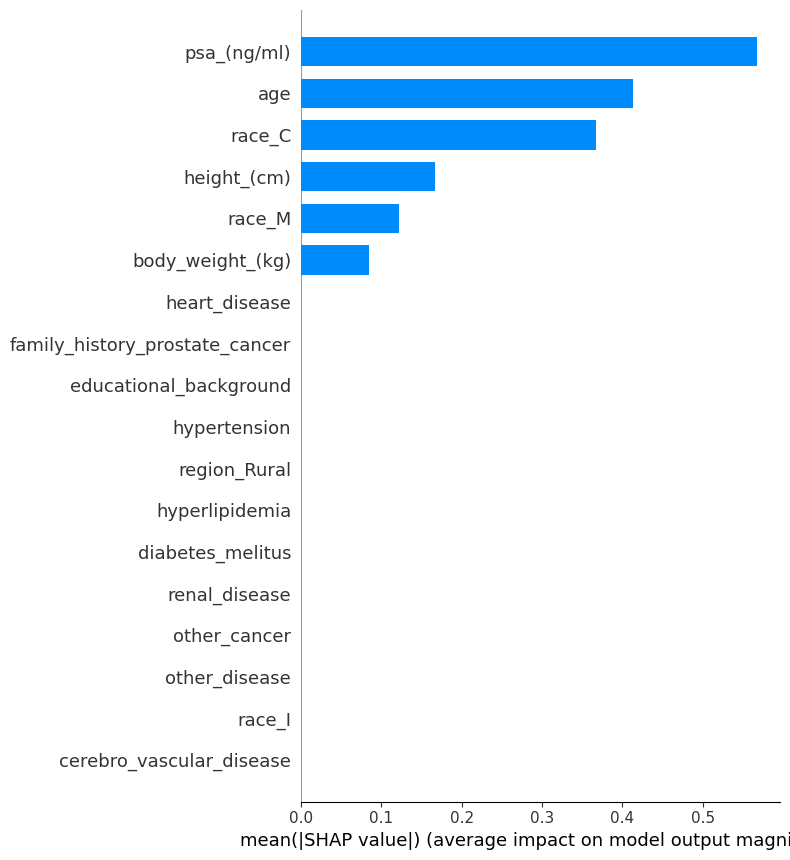

In [70]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test) 

shap.summary_plot(shap_values, X_test, plot_type="bar")

According to the feature importances plot, the most contributing factors to the prostate cancer predictions are psa_(ng/ml) which is fairly reasonable from a medical perspective, as PSA is the most widely used biomarker for prostate cancer risk, and PSA thresholds are used to guide biopsy decisions. Age feature follows, which suggests that a higher age correlates to a higher risk of prostate cancer. This is followed by race (chinese), which indicates that chinese population seems to be more likely to be diagnosed with prostate cancer. However we need to be caution with this analysis, since this might reflect the social determinants of health (SDOH) rather than true biological causation. Next up is height (cm), which seemly suggests that tall stature is associated with a higher prostate cancer risk, possibly through the insulin-like growth factor system, as shown in https://pmc.ncbi.nlm.nih.gov/articles/PMC2566735/. Following is another race-like feature (Malay), which again should be handled with caution, since it seems to be a mixture of biological and socio-environmental signals as mentioned previously. Lastly, body weight (kg) also plays a subtle role, as it suggests being overweight or obese might lead to increased risk of developing an aggressive type of prostate cancer, as shown in https://www.webmd.com/prostate-cancer/prostate-cancer-your-weight.


Knowing psa_(ng/ml) as the most important feature in the data, let's look at how it affects the prediction with a dependency plot:

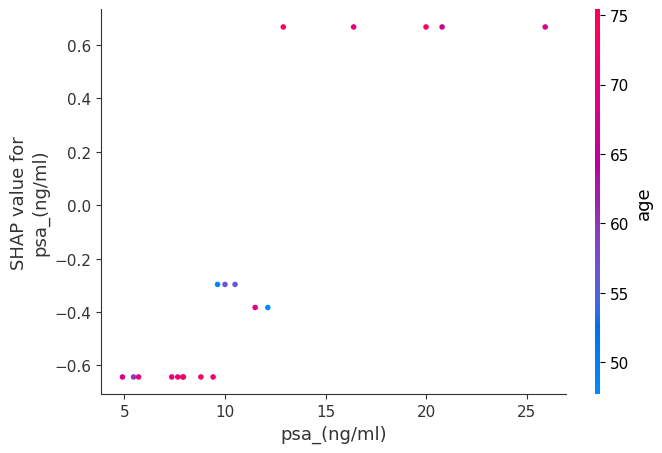

In [71]:
shap.dependence_plot("psa_(ng/ml)", shap_values.values, X_test)

From the dependence plot, we can observe that PSA values in the 5–9 ng/ml range correspond to SHAP values around –0.6, meaning the model associates this range with a reduced probability of prostate cancer. For intermediate PSA values (10–12 ng/ml), the SHAP values move closer to zero (–0.2 to –0.4), suggesting a weaker protective effect and more model uncertainty. For high PSA values (13–25 ng/ml), SHAP values increase to around +0.6, showing that the model strongly links these levels with higher predicted cancer risk.

This pattern is consistent with clinical practice, where prostate cancer risk increases as PSA rises, though PSA values between 4 and 10 ng/ml are often considered a diagnostic “gray zone.” Interestingly, the model appears biased toward interpreting PSA values in this gray zone (5–9 ng/ml) as low risk, which demonstrates the clinical limitation that PSA alone is not a sufficient predictor of prostate cancer.

We can also perform a local model-agnostic explanations on one patient to demonstate how the model arrives at an individual prediction. 

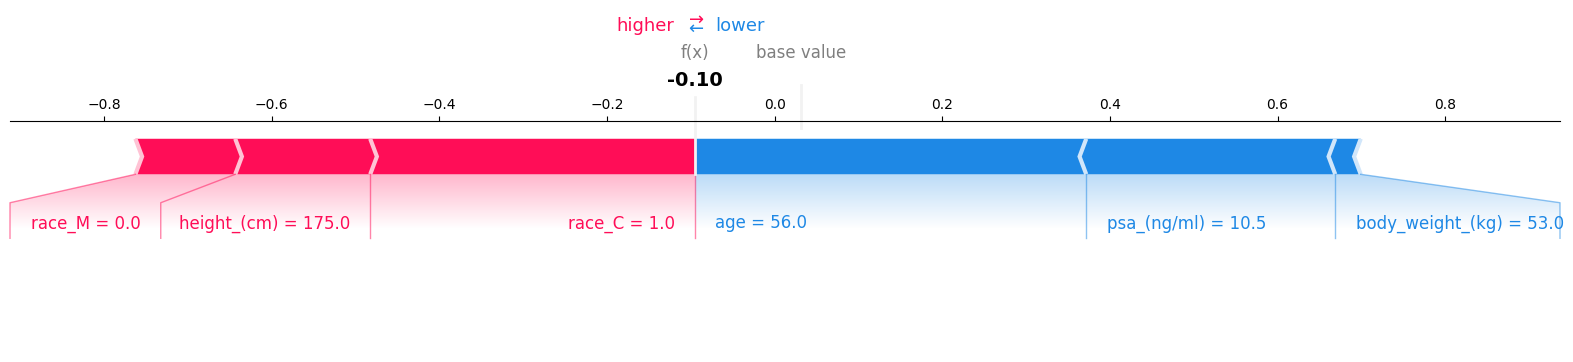

In [72]:
patient_index = 5
shap.force_plot(
    explainer.expected_value,
    shap_values.values[patient_index, :],
    X_test.iloc[patient_index, :],
    matplotlib=True
)

From the force plot above, we can see that the f(x) value is negative, which means that the model predicts a probability below 0.5 for prostate cancer. The red arrow on the left (pushing right) are the features that pushes the prediction higher (towards prostate cancer), with the longest being race_C (Chinese race), followed by height (175 cm). This indicates that, for this specific individual, the model associated these factors with higher prostate cancer risk. 

On the other hand, the model defines the most influential risk-decreasing feature to be age (56), followed by PSA level of 10.5 ng/ml. The model interprets this patient's age and PSA as being relatively protective compared to the higher risk patterns it has learned from the data.

The overall model predicition is f(x) = -0.11 (probability < 0.5), and thus a classification of non-prostate cancer.

*In the force plot, we also observe that race_M (Malay race) appears on the red side, but with a negligible SHAP value (≈ 0). This is not contradictory, rather, it indicates that the feature had no meaningful effect on this patient’s prediction. Its appearance is due to numerical rounding and the way categorical features are represented in SHAP visualizations.

Bias and fairness check with Dalex:

In [73]:
import dalex as dx

X_test_fairness = X_test.copy()

X_test_fairness["race"] = (
    X_test[["race_I", "race_C", "race_M"]]
    .idxmax(axis=1)
    .str.replace("race_", "")   # values: I, C, M
)

explainer = dx.Explainer(
    model,
    X_test,    
    y_test,
    label="XGBoost Prostate Cancer"
)

Preparation of a new explainer is initiated

  -> data              : 19 rows 18 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 19 values
  -> model_class       : lightgbm.sklearn.LGBMClassifier (default)
  -> label             : XGBoost Prostate Cancer
  -> predict function  : <function yhat_proba_default at 0x30c974fe0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0634, mean = 0.456, max = 0.924
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.924, mean = -0.0348, max = 0.868
  -> model_info        : package lightgbm

A new explainer has been created!


In [74]:
explainer.model_parts().plot()

Here, Dalex is showing the importance with respect to the drop-out loss, which is the loss occured if a particular feature is removed. It shows that the model will lose information if hyperlipidemia, age, psa_(ng/ml), diabetus_melitus and race_M was removed. This interpretation shows that the model does not only depend on PSA, but also incorporates comorbidities and demographic factors when estimating prostate cancer risk.

In [75]:
explainer.data["race"] = X_test_fairness["race"].values


In [76]:
mf_tree = explainer.model_fairness(
    protected=explainer.data["race"], 
    privileged="C"
)

mf_tree.plot()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/dalex/fairness/_group_fairness/utils.py:209: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.




Found NaN's or 0's for models: {'XGBoost Prostate Cancer'}
It is advisable to check 'metric_ratios'


Based on the fairness check plot above, both Indian and Malay have Equal opportunity ratio (True positive rate) of 1.5, meaning Indians and Malays are more likely to be correctly identified with prostate cancer than Chinese. This suggests a bias against Chinese population.
As for the predictive parity ratio (precision), Indians have a score of 2.0, meaning the model is much more reliable when predicting prostate cancer in Indian groups, and Malays have equal precision with Chinese. Moving on to predictive equality ratio (False positive rate), Malays have a value of 0.375, meaning Malays patients have lower false positives compared to Chinese, whereas for Indians the false positive rates are similar to Chinese. For the penultimate metric, both Malays and Indians have higher accuracy equality ratio (accuracy) than Chinese, at 1.6 and 2, respectively. Lastly, for the statistical parity ratio (measures if groups are equally likely to get a positive prediction), Malays have a score of 0.6 while Indians have a score of 0.75, meaning that Chinese are more likely to get positive predictions as compared to other race groups, but often these positive predictions are false alarms.

In short, the model is unfair, as the Chinese patients are often disadvantaged, with a lower sensitivity, lower precision and lower overall accuracy. 

In [77]:
mf_tree.metric_scores

,TPR,TNR,PPV,NPV,FNR,FPR,FDR,FOR,ACC,STP
C,0.667,0.333,0.5,0.5,0.333,0.667,0.5,0.5,0.5,0.667
I,1.000,1.000,1.0,1.0,0.000,0.000,0.0,0.0,1.0,0.500
M,1.000,0.750,0.5,1.0,0.000,0.250,0.5,0.0,0.8,0.400


Looking at the group fairness metrics table, we observe for each race groups:

Chinese:
- True Positive Rate - 0.667 -> Model correctly identifies 66.7% of positive cases in the group.
- True Negative Rate - 0.333 -> Model correctly rejects 33.3% of negatives cases.
- Accuracy - 0.5 -> Model prediction accuracy is 50% for Chinese.
- Overall risk -> More false positives than other race groups.

Indians:
- True Positive Rate - 1 -> Perfect identification on positive cases.
- True Negative Rate - 1 -> Perfect identification on negative cases.
- Accuracy - 0.5 -> Flawless accuracy, probably due to the small sample size as found previously.
- Overall risk -> Looks perfect at a glance, however there could be underlying data imbalance issue.

Malays:
- True Positive Rate - 1 -> Perfect identification on positive cases.
- True Negative Rate - 0.75 -> Model correctly rejects 75% of negatives cases.
- Accuracy - 0.8 -> Higher accuracy of 80%, which is better than Chinese, but lower than Indians.
- Overall risk -> More balance than Chinese, but false positives are still present (FDR = 0.5).


In [78]:
mf_tree.fairness_check()

Bias detected in 5 metrics: TPR, ACC, PPV, FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on 'C'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
       TPR  ACC  PPV       FPR       STP
I  1.49925  2.0  2.0       NaN  0.749625
M  1.49925  1.6  1.0  0.374813  0.599700

Warning!
Take into consideration that NaN's are present, consider checking 'metric_scores' plot to see the difference


Above fairness check once again proves that the model treats Indians and Malays to have higher true positive rates and accuracy but lower overall positive predictions compared to Chinese, which is a statistical bias.

Further bias check:

The reason for our model bias is likely because the existence of a feature that correlates with the race features, and that leads to the model being able to reconstruct a patient's racial identity. We can identify the described features using correlation coefficient.



In [79]:
df_bias_aware = df_final.copy()

race_cols = ['race_C', 'race_I', 'race_M']

df_bias_aware['race'] = df_bias_aware[race_cols].idxmax(axis=1).str.replace('race_', '')

df_bias_aware.drop(race_cols, axis=1, inplace=True)

In [80]:
df_bias_aware['race'].value_counts()

race
C    42
M    38
I    11
Name: count, dtype: int64

In [81]:
df_bias_aware.drop('race', axis=1).corrwith(df_bias_aware['race'] == 'C').sort_values()

educational_background           -0.177771
diabetes_melitus                 -0.174740
hyperlipidemia                   -0.149150
body_weight_(kg)                 -0.149049
other_disease                    -0.126500
region_Rural                     -0.125357
hypertension                     -0.123726
renal_disease                    -0.043373
psa_(ng/ml)                      -0.032045
heart_disease                    -0.022272
age                               0.092494
family_history_prostate_cancer    0.109323
height_(cm)                       0.117636
cerebro_vascular_disease          0.124073
other_cancer                      0.199431
grouping                          0.222718
dtype: float64

We see that other_cancer, educational background, and diabetes mellitus being the most correlated features to race.

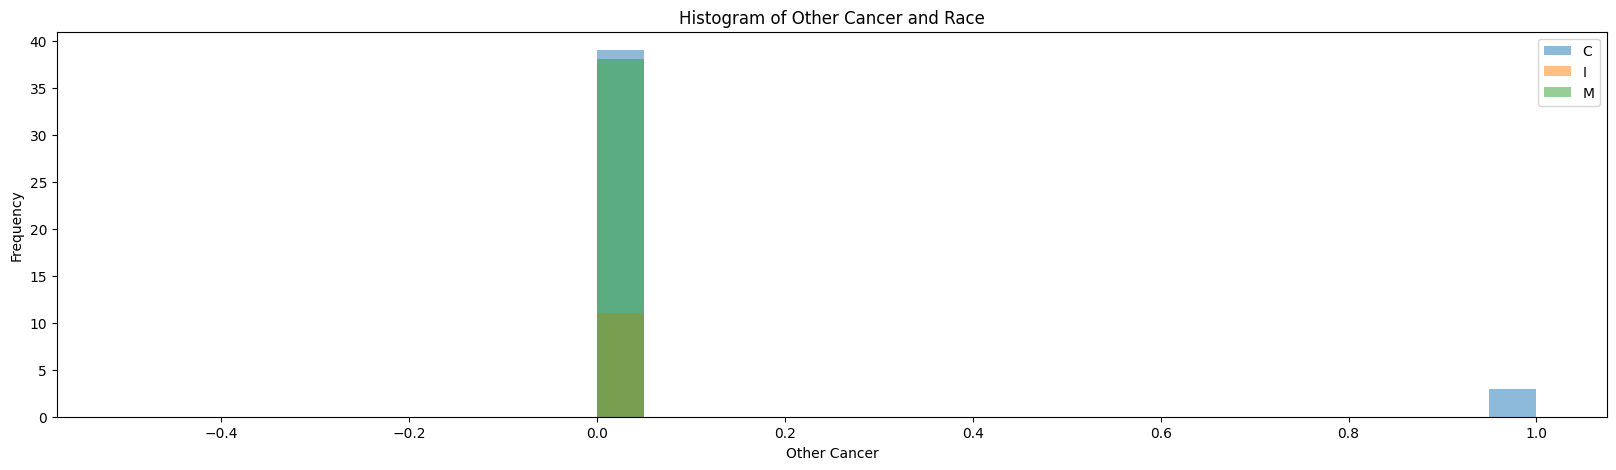

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
C,42.0,0.071429,0.260661,0.0,0.0,0.0,0.0,1.0
I,11.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
M,38.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [82]:
df_bias_aware.groupby('race')['other_cancer'].plot(
    kind='hist',
    figsize=(20,5),
    alpha=0.5,       
    legend=True,
    bins=20,
    title='Histogram of Other Cancer and Race'
)

plt.xlabel('Other Cancer')
plt.show()

df_bias_aware.groupby('race')['other_cancer'].describe()

According to the table above, only race C (chinese) have a few case (< 5) of other cancer history. With other races having 0 cases. The weak positive correlation of 0.19943 indicates that being in race C slightly increases the chance of other_cancer in the dataset. However, due to the low mean value of 0.07, it is not a major concern and there is very little data to cause a bias effect to the dataset. Therefore, it is unlikely to be a meaningful proxy for race feature. We can ignore this feature for now and move on to educational background feature.

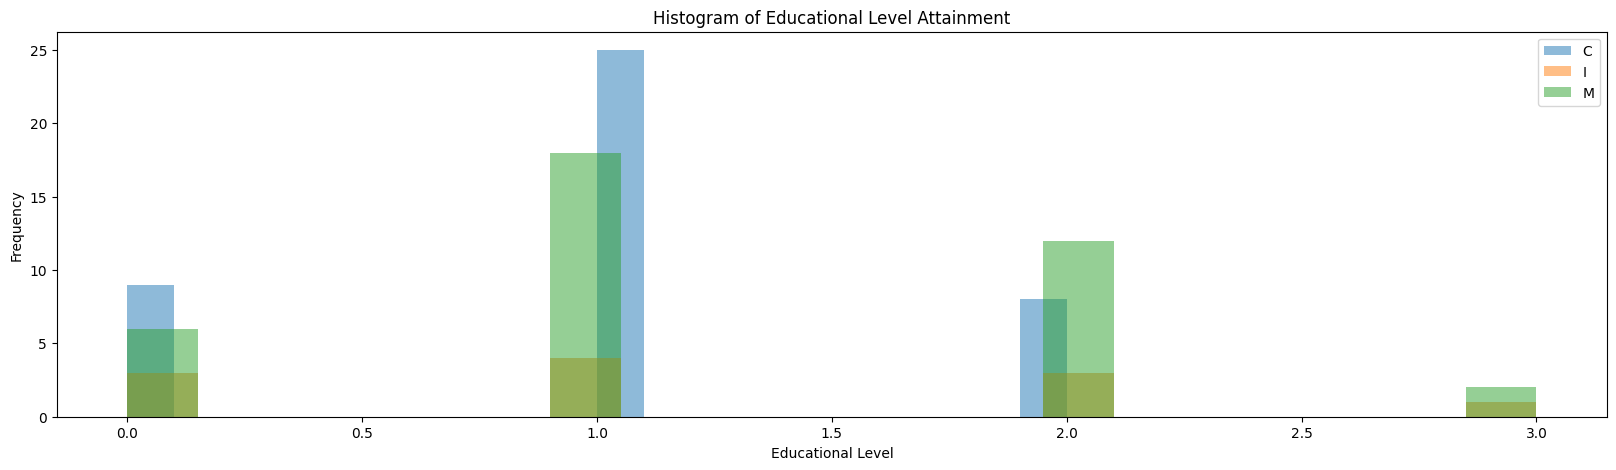

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
C,42.0,0.976190,0.643470,0.0,1.0,1.0,1.0,2.0
I,11.0,1.181818,0.981650,0.0,0.5,1.0,2.0,3.0
M,38.0,1.263158,0.794719,0.0,1.0,1.0,2.0,3.0


In [83]:
df_bias_aware.groupby('race')['educational_background'].plot(
    kind='hist',
    figsize=(20,5),
    alpha=0.5,       
    legend=True,
    bins=20,
    title='Histogram of Educational Level Attainment'
)

plt.xlabel('Educational Level')
plt.show()

df_bias_aware.groupby('race')['educational_background'].describe()

The distribution above does not show any significant difference about each race, therefore there isn't much impact to the overall bias in the dataset. Since the mean education level of race M (Malay) have a higher mean value than other races, the model sees Malay race as a predictive of slightly higher education level, and race C (Chinese) as a predictive of a lower one.

However, it is important to note that, correlation does not mean that race causes education level attainment, instead it implies that both race and education are not independent, probably due to sampling bias, or real-world structural inequities.

From the context of bias, it means that including education as a predictor can reintroduce race information into the prediction, even if we choose not to include the race feature.

Lastly, we will move on to diabetes mellitus feature.

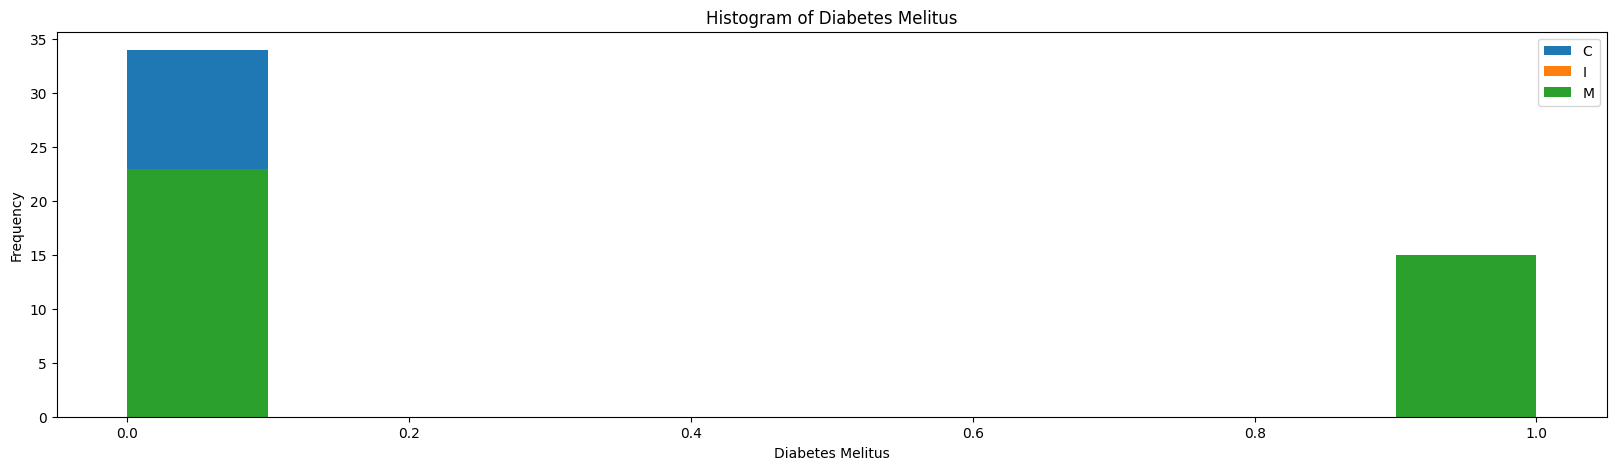

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
C,42.0,0.190476,0.397437,0.0,0.0,0.0,0.0,1.0
I,11.0,0.181818,0.404520,0.0,0.0,0.0,0.0,1.0
M,38.0,0.394737,0.495355,0.0,0.0,0.0,1.0,1.0


In [84]:
df_bias_aware.groupby('race')['diabetes_melitus'].plot(
    kind='hist',
    figsize=(20,5),
    title='Histogram of Diabetes Melitus',
    legend=True
)
plt.xlabel('Diabetes Melitus')
plt.show()

df_bias_aware.groupby('race')['diabetes_melitus'].describe()

We can see that race M (Malays) have nearly double the mean of other races of diabetes melitus cases, with 75th percentile of 1, indicating that a substantial portion of Malay individuals have diabetes, while most Chinese and Indian individuals don't. Therefore the feature 'diabetes_melitus' is correlated with race, particularly race M vs others. Through this feature, the model might learn patterns that indirectly distinguish race, even if race itself is not included. This is a proxy variable, and will potentially introduce bias.

However, since these 3 features are only slightly correlated, it is generally not a strong source of bias, as we will therefore leave it as it is.

To truly eliminate the source of bias then, we need a more sophisticated bias mitigation technique like DIR.

In [85]:
from aif360.datasets import BinaryLabelDataset

df_aif = df_final.copy()

race_cols = ['race_C', 'race_I', 'race_M']

df_aif['race'] = df_aif[race_cols].idxmax(axis=1).str.replace('race_', '').map({'C':0,'I':1,'M':2})
df_aif.drop(race_cols, axis=1, inplace=True)

dataset = BinaryLabelDataset(
    df=df_aif,
    label_names=['grouping'],          
    protected_attribute_names=['race'],
    favorable_label=1,
    unfavorable_label=0
)

In [86]:
from aif360.algorithms.preprocessing import DisparateImpactRemover

di = DisparateImpactRemover(repair_level=1.0)

dataset_transf = di.fit_transform(dataset)

df_transf = dataset_transf.convert_to_dataframe()[0] 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


In [87]:
df_transf.head()

,age,psa_(ng/ml),body_weight_(kg),height_(cm),family_history_prostate_cancer,educational_background,hypertension,heart_disease,cerebro_vascular_disease,hyperlipidemia,diabetes_melitus,renal_disease,other_cancer,other_disease,region_Rural,race,grouping
0,68.0,7.65,70.0,172.0,1.0,3.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,60.0,10.50,68.0,178.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,77.0,5.41,70.0,170.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,60.0,8.87,84.0,157.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,77.0,5.41,53.0,160.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,0.0


In [88]:
df_transf['race'] = df_transf['race'].round().astype(int)  # make sure it's integer

# Map numeric back to original labels
race_map = {0: 'C', 1: 'I', 2: 'M'}
df_transf['race_label'] = df_transf['race'].map(race_map)

# Create OHE columns
df_transf['race_C'] = (df_transf['race_label'] == 'C').astype(int)
df_transf['race_I'] = (df_transf['race_label'] == 'I').astype(int)
df_transf['race_M'] = (df_transf['race_label'] == 'M').astype(int)

# Drop the helper columns if desired
df_transf.drop(['race', 'race_label'], axis=1, inplace=True)

In [89]:
from sklearn.model_selection import train_test_split

X = df_transf.drop(columns=['grouping'])  
y = df_transf['grouping']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [90]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [91]:
import optuna
from optuna.samplers import TPESampler

from sklearn.metrics import roc_auc_score

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1
    }

    model = LGBMClassifier(**param)
    model.fit(X_train_res, y_train_res)
    y_prob = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    return auc  

sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=100)  

print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

best_params = study.best_params
best_model = LGBMClassifier(**best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train_res, y_train_res)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

[I 2026-03-26 13:46:26,977] A new study created in memory with name: no-name-465f433f-35b9-4941-bdca-96620f7eeb6c
[I 2026-03-26 13:46:27,230] Trial 0 finished with value: 0.5568181818181818 and parameters: {'n_estimators': 437, 'max_depth': 12, 'num_leaves': 115, 'learning_rate': 0.07661100707771368, 'min_child_samples': 19, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469887, 'reg_lambda': 0.002570603566117596}. Best is trial 0 with value: 0.5568181818181818.
[I 2026-03-26 13:46:27,361] Trial 1 finished with value: 0.6363636363636364 and parameters: {'n_estimators': 737, 'max_depth': 3, 'num_leaves': 147, 'learning_rate': 0.1696753360719655, 'min_child_samples': 25, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 5.472429642032189e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 1 with value: 0.6363636363636364.
[I 2026-03-26 13:46:27,439] Trial 2 finished with value: 0.6988636363636364 and

Best AUC: 0.8125
Best params: {'n_estimators': 341, 'max_depth': 3, 'num_leaves': 74, 'learning_rate': 0.010429263327272438, 'min_child_samples': 28, 'subsample': 0.9697578627455049, 'colsample_bytree': 0.7620403301895196, 'reg_alpha': 5.392267745505152e-07, 'reg_lambda': 0.0010259288465758326}
Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.73      0.76        11
         1.0       0.67      0.75      0.71         8

    accuracy                           0.74        19
   macro avg       0.73      0.74      0.73        19
weighted avg       0.74      0.74      0.74        19

AUC: 0.8125


In [92]:
import joblib
joblib.dump(best_model, "../models/lgbm_clinical.joblib")

['../models/lgbm_clinical.joblib']

In [93]:
import dalex as dx

X_test_fairness = X_test.copy()

X_test_fairness["race"] = (
    X_test[["race_I", "race_C", "race_M"]]
    .idxmax(axis=1)
    .str.replace("race_", "")   # values: I, C, M
)

explainer = dx.Explainer(
    model,
    X_test,    
    y_test,
    label="XGBoost Prostate Cancer"
)

Preparation of a new explainer is initiated

  -> data              : 19 rows 18 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 19 values
  -> model_class       : lightgbm.sklearn.LGBMClassifier (default)
  -> label             : XGBoost Prostate Cancer
  -> predict function  : <function yhat_proba_default at 0x30c974fe0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.043, mean = 0.372, max = 0.924
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.721, mean = 0.0493, max = 0.901
  -> model_info        : package lightgbm

A new explainer has been created!


In [94]:
explainer.data["race"] = X_test_fairness["race"].values

mf_tree = explainer.model_fairness(
    protected=explainer.data["race"], 
    privileged="C"
)

mf_tree.fairness_check()

Bias detected in 3 metrics: ACC, FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on 'C'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
   TPR       ACC  PPV       FPR       STP
I  NaN  1.501502  NaN       NaN       NaN
M  NaN  1.801802  NaN  1.501502  3.592814

Warning!
Take into consideration that NaN's are present, consider checking 'metric_scores' plot to see the difference


After applying the DisparateImpactRemover, the model shows a reduction in the number of fairness metrics flagged: from five metrics (TPR, ACC, PPV, FPR, STP) before repair to three metrics (ACC, FPR, STP) after repair. This indicates that the preprocessing partially mitigated bias, particularly in TPR and PPV, which became unstable or NaN due to small subgroup sizes. However, some disparities worsened, most notably, the accuracy (ACC) and statistical parity (STP) ratios for the M subgroup increased, suggesting that while the repair improved certain fairness aspects, it did not fully balance predictions across all racial groups. Overall, the intervention had a mixed effect: it reduced bias in some metrics but introduced instability or worsened disparities in others, highlighting the need for additional fairness-aware methods.

Nevertheless, this change increased the AUC of the model from 0.7727 to 0.8125, while accuracy also increased from 0.68 to 0.74. This suggests that the Disparate Impact Remover not only addressed certain fairness concerns but also improved the overall predictive performance of the model. However, it is important to note that some fairness metrics, such as ACC, FPR, and STP for the M subgroup, remained outside the acceptable range, indicating persistent disparities. Therefore, while the preprocessing step enhanced model performance and partially mitigated bias, additional measures such as reweighting, adversarial debiasing, or post-processing methods, may be necessary to achieve a more comprehensive and equitable model across all protected groups.

*Last Updated: 27 September 2025 by Justin Tan*

Pipeline for deployment: